In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Airbnb_India_Top_500.csv")
#df=pd.read_csv("/kaggle/input/indias-airbnb-gems-2024-trending-picks/Airbnb_India_Top_500.csv")

In [4]:
df.head(10)

,address,isHostedBySuperhost,location/lat,location/lng,name,numberOfGuests,pricing/rate/amount,roomType,stars
0,"Manali, Himachal Pradesh, India",False,32.22330,77.18228,HighQ Manali / Deluxe Room,3,8946,Room in hotel,NaN
1,"Manali, Himachal Pradesh, India",False,32.22352,77.18152,Highq manali / 3 BHK Cottage,9,9124,Room in hotel,NaN
2,"Goa, India",False,15.50400,73.86600,Best view of the river from your terrace 04,4,9900,Private room in home,4.00
3,"Bhuntar, Himachal Pradesh, India",False,31.88656,77.14467,Shabashe,1,8684,Shared room in rental unit,NaN
4,"Jaipur, Rajasthan, India",False,26.85991,75.66909,Luxurious Independent Studio with Wifi & Kitchen,1,20690,Entire condo,4.75
5,"Bhuntar, Himachal Pradesh, India",False,32.01248,77.29114,Aman Palace Guest House Kasol With Super Delux...,3,4274,Room in hotel,NaN
6,"Bhuntar, Himachal Pradesh, India",False,32.01204,77.29090,Aman Palace Guest House Kasol With Deluxe Room,2,4274,Room in hotel,NaN
7,"Gurugram, Haryana, India",True,28.36673,77.00647,Boutique destination wedding experience 50pax...,16,1734,Farm stay,NaN
8,"Ganaheda, Rajasthan, India",False,26.49372,74.53830,Lux farm resort with pool - Villa,12,1804,Farm stay,NaN
9,"Banjar, Himachal Pradesh, India",False,31.63839,77.34503,Deluxe Room,3,2822,Room in hotel,NaN


In [7]:
df.columns

Index(['address', 'isHostedBySuperhost', 'location/lat', 'location/lng',
       'name', 'numberOfGuests', 'pricing/rate/amount', 'roomType', 'stars'],
      dtype='object')

In [8]:
df['address'].unique().tolist()

['Manali, Himachal Pradesh, India',
 'Goa, India',
 'Bhuntar, Himachal Pradesh, India',
 'Jaipur, Rajasthan, India',
 'Gurugram, Haryana, India',
 'Ganaheda, Rajasthan, India',
 'Banjar, Himachal Pradesh, India',
 'Morjim, Goa, India',
 'Awas, Maharashtra, India',
 'Bengaluru, Karnataka, India',
 'Sangolda, Goa, India',
 'Rishikesh, Uttarakhand, India',
 'Parra, Goa, India',
 'New Delhi, Delhi, India',
 'Aru, India',
 'North Goa, Goa, India',
 'Mararikulam, Kerala, India',
 'Canacona, Goa, India',
 'Nainital, Uttarakhand, India',
 'Pathau, Uttarakhand, India',
 'Anjuna, Goa, India',
 'Nathuwakhan, Uttarakhand, India',
 'Loutolim, Goa, India',
 'Candolim, Goa, India',
 'Karjat, Maharashtra, India',
 'Assagao, Goa, India',
 'Panna, Madhya Pradesh, India',
 'Nashik, Maharashtra, India',
 'Mumbai, Maharashtra, India',
 'Kullu, Himachal Pradesh, India',
 'Lonavla, Maharashtra, India',
 'Nerul, Goa, India',
 'SALIGAO, Goa, India',
 'Ribandar, Goa, India',
 'Arpora, Goa, India',
 'Guirim, Goa

In [9]:
df.shape

(500, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   address              500 non-null    object 
 1   isHostedBySuperhost  500 non-null    bool   
 2   location/lat         500 non-null    float64
 3   location/lng         500 non-null    float64
 4   name                 500 non-null    object 
 5   numberOfGuests       500 non-null    int64  
 6   pricing/rate/amount  500 non-null    int64  
 7   roomType             500 non-null    object 
 8   stars                196 non-null    float64
dtypes: bool(1), float64(3), int64(2), object(3)
memory usage: 31.9+ KB


In [11]:
df.isnull().sum()

address                  0
isHostedBySuperhost      0
location/lat             0
location/lng             0
name                     0
numberOfGuests           0
pricing/rate/amount      0
roomType                 0
stars                  304
dtype: int64

In [12]:
df['pricing/rate/amount'] = df['pricing/rate/amount'].replace('[₹,]', '', regex=True).astype(float)

In [13]:
df.rename(columns={
    'pricing/rate/amount': 'price',
    'location/lat': 'latitude',
    'location/lng': 'longitude'
}, inplace=True)

In [14]:
df.columns

Index(['address', 'isHostedBySuperhost', 'latitude', 'longitude', 'name',
       'numberOfGuests', 'price', 'roomType', 'stars'],
      dtype='object')

### Price Distribution

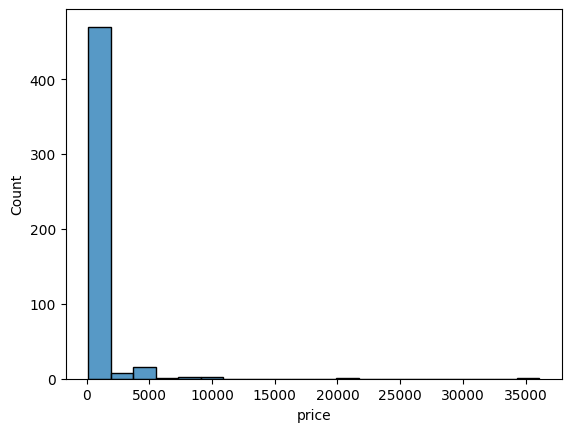

In [16]:
sns.histplot(df['price'], bins=20)
plt.show()

<Axes: xlabel='roomType'>

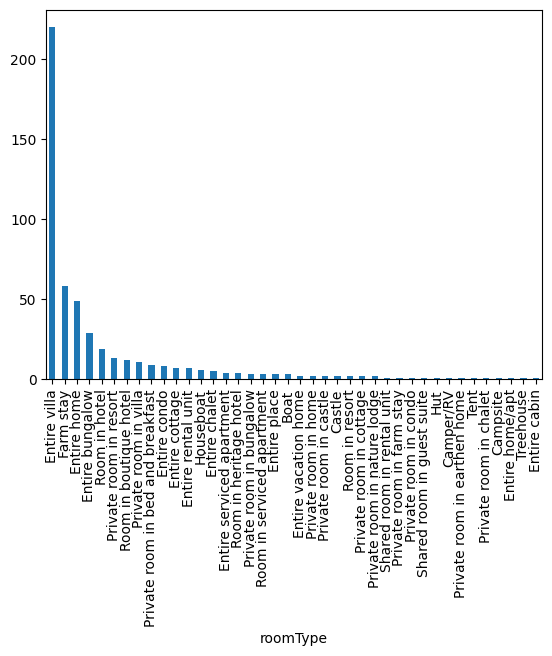

In [17]:
df['roomType'].value_counts().plot(kind='bar')

In [18]:
df['roomType'].unique().tolist()

['Room in hotel',
 'Private room in home',
 'Shared room in rental unit',
 'Entire condo',
 'Farm stay',
 'Entire villa',
 'Private room in resort',
 'Entire cottage',
 'Entire home',
 'Room in boutique hotel',
 'Entire serviced apartment',
 'Boat',
 'Private room in villa',
 'Entire bungalow',
 'Shared room in guest suite',
 'Room in heritage hotel',
 'Private room in bed and breakfast',
 'Entire rental unit',
 'Private room in castle',
 'Private room in condo',
 'Entire place',
 'Houseboat',
 'Entire chalet',
 'Private room in farm stay',
 'Private room in nature lodge',
 'Tent',
 'Hut',
 'Room in serviced apartment',
 'Private room in earthen home',
 'Room in resort',
 'Camper/RV',
 'Castle',
 'Entire vacation home',
 'Private room in chalet',
 'Entire home/apt',
 'Campsite',
 'Private room in bungalow',
 'Private room in cottage',
 'Treehouse',
 'Entire cabin']

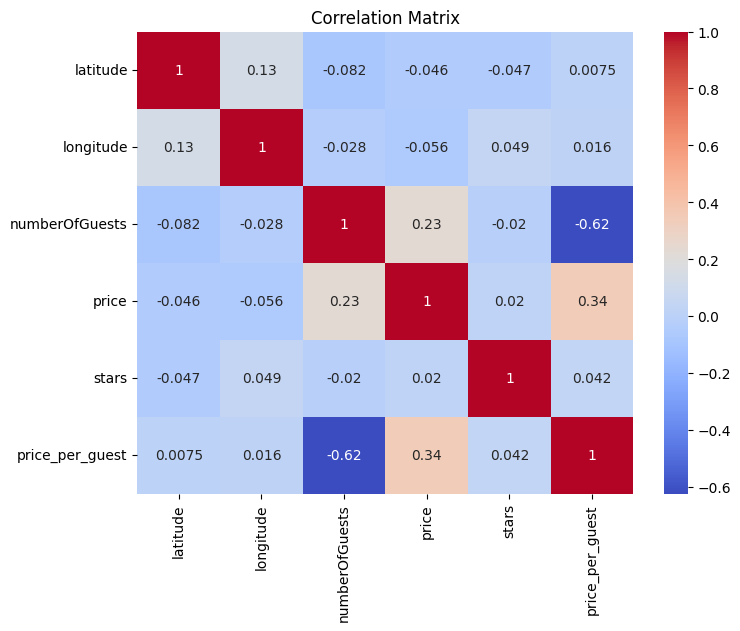

In [29]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Strong positive (> 0.6)

Strong negative (< -0.6)

## Price vs. Guest Capacity

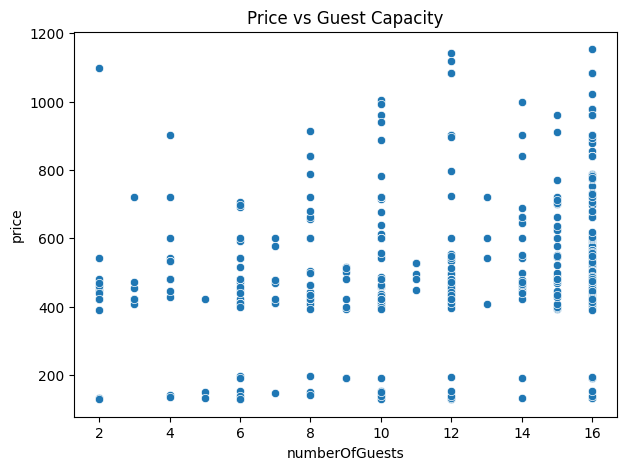

In [30]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='numberOfGuests', y='price', data=df)
plt.title("Price vs Guest Capacity")
plt.show()

## Price vs. Ratings

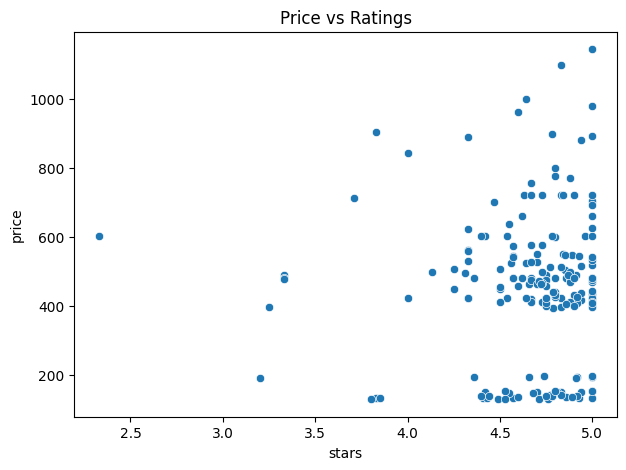

In [34]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='stars', y='price', data=df)
plt.title("Price vs Ratings")
plt.show()

<Axes: xlabel='stars', ylabel='price'>

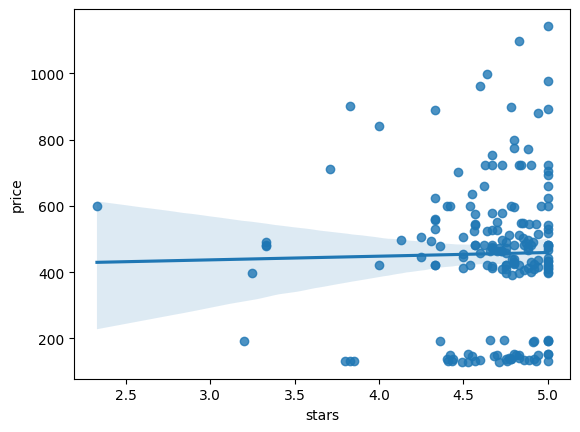

In [35]:
sns.regplot(x='stars', y='price', data=df)

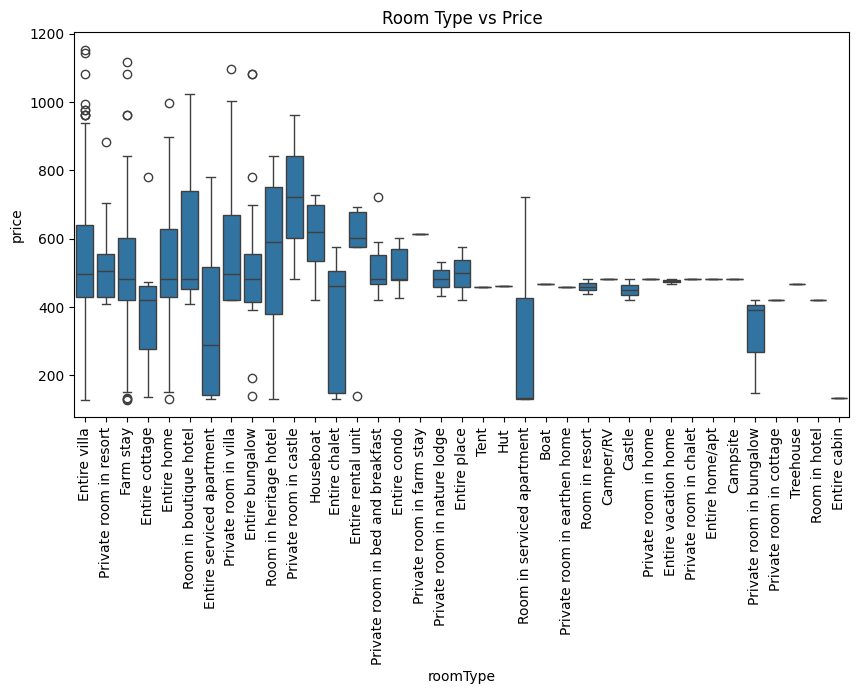

In [43]:
plt.figure(figsize=(10,5))
sns.boxplot(x='roomType', y='price', data=df)
plt.xticks(rotation=90)
plt.title("Room Type vs Price")
plt.show()

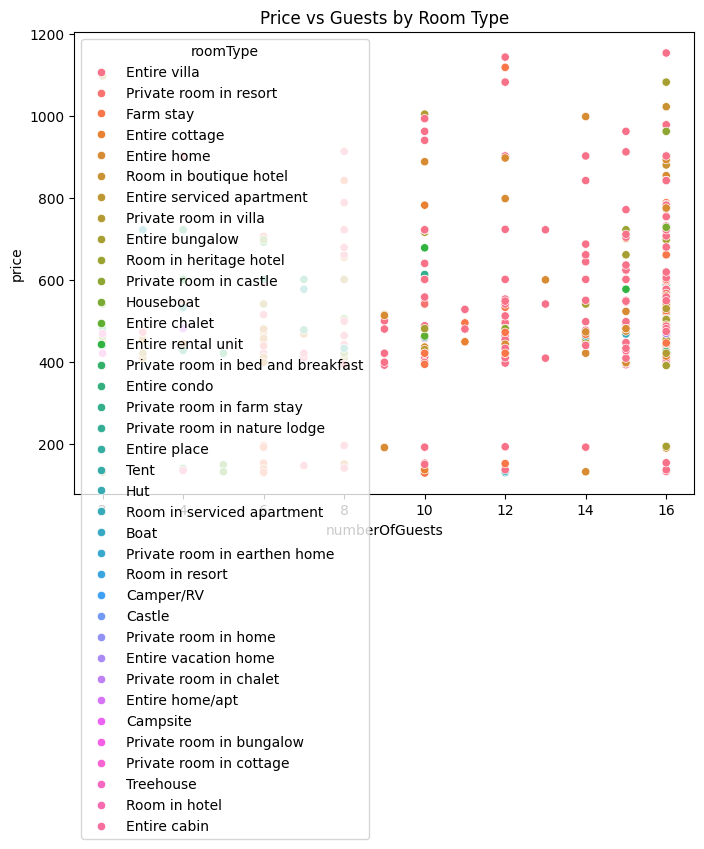

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='numberOfGuests',
    y='price',
    hue='roomType',
    data=df
)

plt.title("Price vs Guests by Room Type")
plt.show()

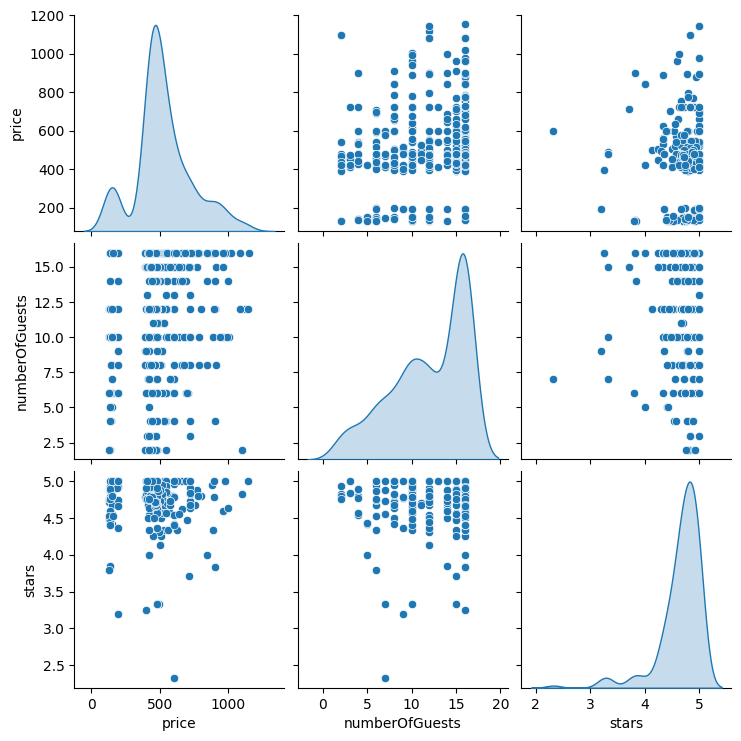

In [50]:
sns.pairplot(df[['price','numberOfGuests','stars']], diag_kind='kde')
plt.show()

## Geographic relations

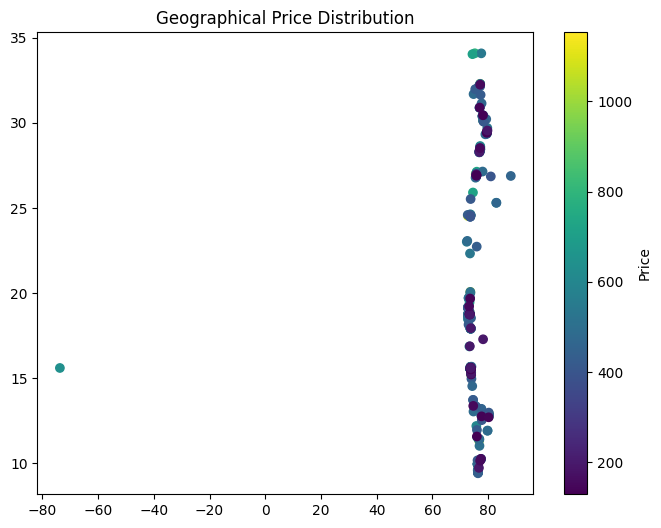

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(df['longitude'], df['latitude'], 
            c=df['price'], cmap='viridis')
plt.colorbar(label='Price')
plt.title("Geographical Price Distribution")
plt.show()

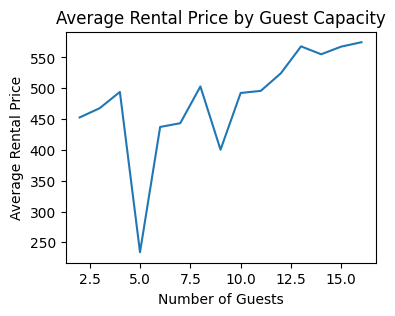

In [55]:
price_by_capacity = df.groupby('numberOfGuests')['price'].mean().reset_index()

# Plot the result
plt.figure(figsize=(4,3))
sns.lineplot(x='numberOfGuests', y='price', data=price_by_capacity)
plt.title('Average Rental Price by Guest Capacity')
plt.xlabel('Number of Guests')
plt.ylabel('Average Rental Price')
plt.show()

In [52]:
df.groupby('roomType')['price'].mean().sort_values(ascending=False)

roomType
Private room in castle               721.500000
Private room in farm stay            613.000000
Room in boutique hotel               606.181818
Houseboat                            603.333333
Private room in villa                602.700000
Entire villa                         541.254902
Room in heritage hotel               539.000000
Entire rental unit                   537.600000
Private room in resort               537.545455
Entire home                          532.808511
Entire bungalow                      523.074074
Private room in bed and breakfast    517.625000
Entire condo                         511.666667
Farm stay                            505.782609
Entire place                         499.000000
Private room in nature lodge         482.500000
Campsite                             481.000000
Private room in home                 481.000000
Private room in chalet               481.000000
Camper/RV                            481.000000
Entire home/apt                

In [53]:
df.groupby('isHostedBySuperhost')['price'].mean()

isHostedBySuperhost
False    534.723464
True     482.763158
Name: price, dtype: float64

# Conclusion
I performed exploratory data analysis on 500 Airbnb listings across India to identify pricing drivers and market patterns. After cleaning and preprocessing the data, I analyzed relationships between price, guest capacity, room type, ratings, and host status. The analysis revealed that room type and accommodation capacity are the strongest predictors of rental pricing, with noticeable geographic clustering in premium locations.